In [27]:
print("House Price Prediction Project Started!")


House Price Prediction Project Started!


In [28]:
import sys
print(sys.executable)

/Users/nikini_fdo/Documents/House-Price-Prediction/venv/bin/python


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import xgboost

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [47]:
df = pd.read_csv("data/train.csv")

In [41]:
os.listdir("data")

['train.csv']

In [49]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [53]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [57]:
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

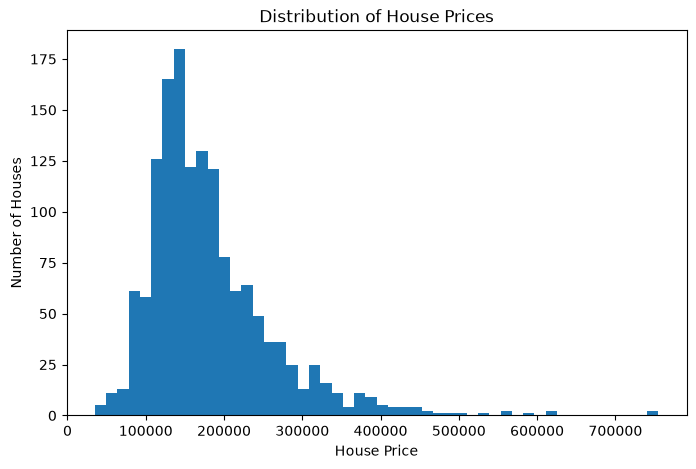

In [59]:
plt.figure(figsize=(8,5))

plt.hist(df['SalePrice'], bins=50)

plt.xlabel("House Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices")

plt.show()

In [63]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [65]:
correlation = df.corr(numeric_only=True)

correlation['SalePrice'].sort_values(ascending=False).head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

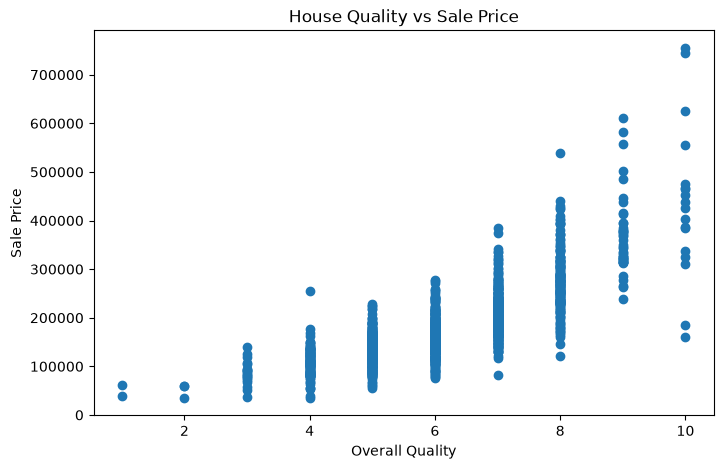

In [67]:
plt.figure(figsize=(8,5))

plt.scatter(df['OverallQual'], df['SalePrice'])

plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("House Quality vs Sale Price")

plt.show()

In [69]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [73]:
numeric_features = X.select_dtypes(include=['int64','float64']).columns
categorical_features = X.select_dtypes(include=['str']).columns

print("Numeric:", len(numeric_features))
print("Categorical:", len(categorical_features))

Numeric: 37
Categorical: 43


In [75]:
X[numeric_features] = X[numeric_features].fillna(
    X[numeric_features].median()
)

In [77]:
X[categorical_features] = X[categorical_features].fillna("None")

In [79]:
X.isnull().sum().sum()

np.int64(0)

In [81]:
X_encoded = pd.get_dummies(X)

In [83]:
X_encoded.shape

(1460, 304)

In [85]:
X_encoded.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,True,False,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,True,False,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,True,False,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,True,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,True,False,False,False,False,True,False


In [ ]:
X_train.shape, X_test.shape

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [89]:
X_train.shape, X_test.shape

((1168, 304), (292, 304))

In [103]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()

In [91]:
linear_model = LinearRegression()

In [ ]:
linear_model.fit(X_train, y_train)

In [107]:
linear_predictions = linear_model.predict(X_test)

In [97]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [109]:
linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

linear_r2 = r2_score(
    y_test, 
    linear_predictions
)

print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R2:", linear_r2)

Linear Regression RMSE: 29395.168285044114
Linear Regression R2: 0.8873482176421101


In [111]:
from sklearn.ensemble import RandomForestRegressor

In [113]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [115]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [117]:
rf_predictions = rf_model.predict(X_test)

In [119]:
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest RMSE: 29003.311939316045
Random Forest R2: 0.8903316390036877


In [122]:
from xgboost import XGBRegressor

In [126]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [128]:
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [130]:
xgb_predictions = xgb_model.predict(X_test)

In [132]:
xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_predictions)
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R2:", xgb_r2)

XGBoost RMSE: 25713.173588649068
XGBoost R2: 0.913801908493042


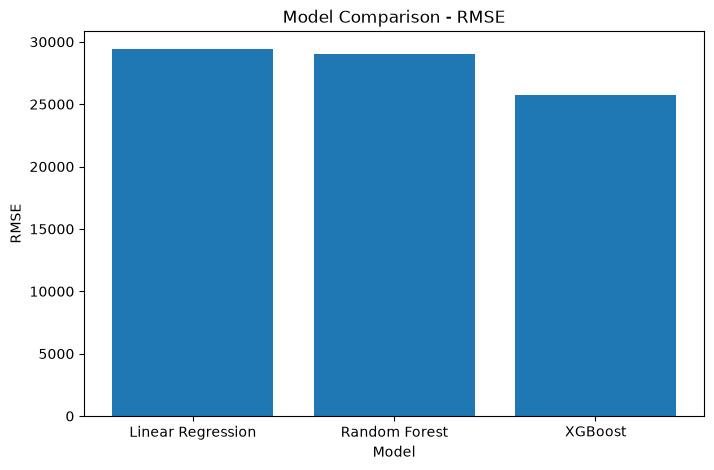

In [134]:
models = ['Linear Regression', 'Random Forest', 'XGBoost']
rmse_values = [linear_rmse, rf_rmse, xgb_rmse]

plt.figure(figsize=(8, 5))

plt.bar(models, rmse_values)

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Model Comparison - RMSE")

plt.show()

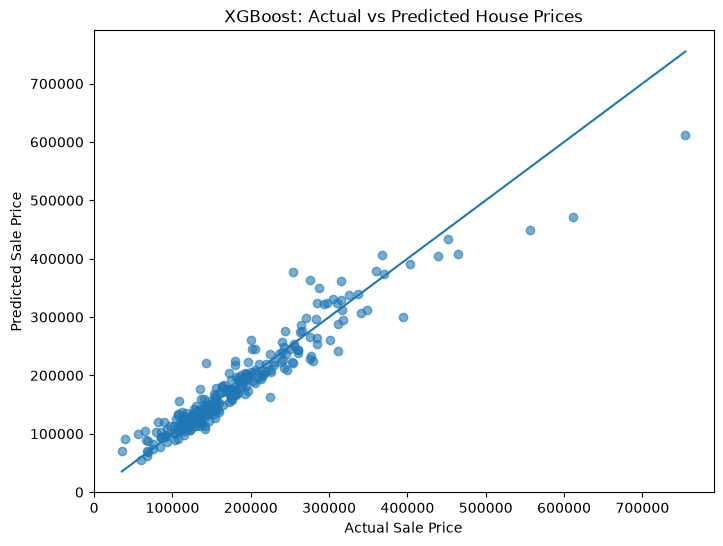

In [136]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, xgb_predictions, alpha=0.6)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("XGBoost: Actual vs Predicted House Prices")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

In [138]:
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

feature_importance.head(15)

FullBath             0.216851
OverallQual          0.136055
BsmtQual_Ex          0.082786
GarageCars           0.075931
GrLivArea            0.032690
KitchenQual_Gd       0.030699
ExterQual_Ex         0.029369
KitchenQual_Ex       0.028883
CentralAir_N         0.024842
LandContour_Bnk      0.020700
Fireplaces           0.020549
2ndFlrSF             0.016839
GarageType_Attchd    0.015635
MSZoning_RM          0.015209
TotalBsmtSF          0.015161
dtype: float32

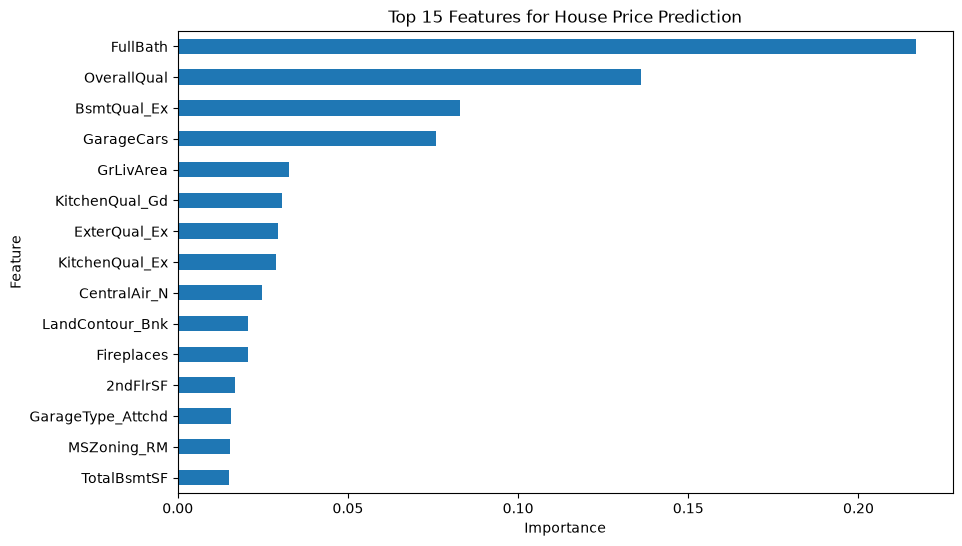

In [140]:
plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(kind='barh')

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features for House Price Prediction")

plt.show()

In [142]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2,
        xgb_r2
    ]
})

results

,Model,RMSE,R2
0,Linear Regression,29395.168285,0.887348
1,Random Forest,29003.311939,0.890332
2,XGBoost,25713.173589,0.913802


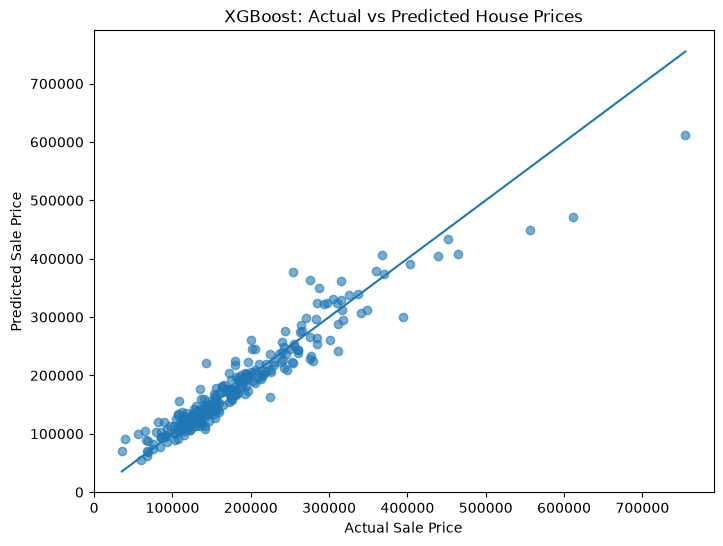

In [144]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, xgb_predictions, alpha=0.6)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("XGBoost: Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.savefig("images/actual_vs_predicted.png", dpi=300, bbox_inches="tight")

plt.show()

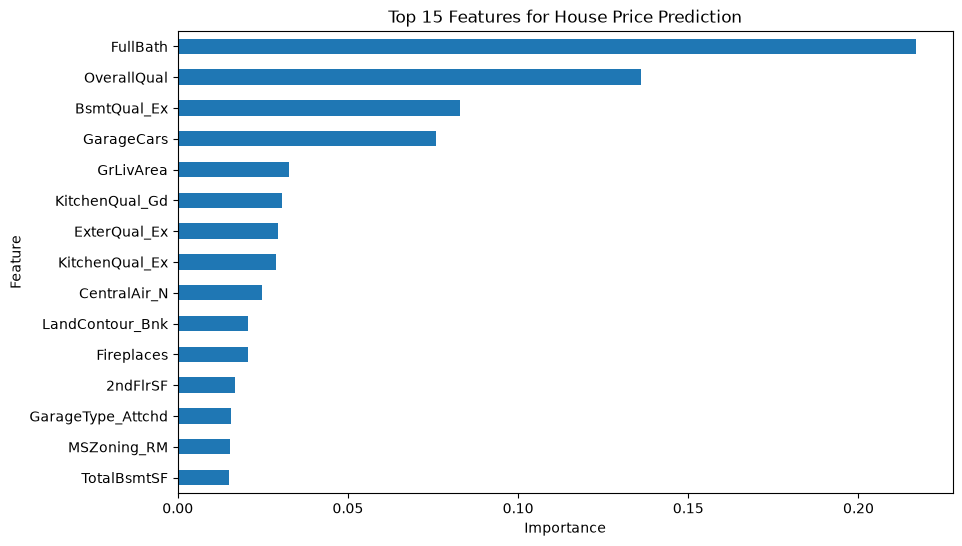

In [146]:
plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(kind='barh')

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features for House Price Prediction")

plt.savefig("images/feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

In [148]:
plt.savefig(
    "images/model_comparison_rmse.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [152]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

In [154]:
param_grid = {
    'n_estimators': [300, 500, 700, 1000],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

In [156]:
xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42
    ),
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [160]:
xgb_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], 'n_estimators': [300, 500, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``Randomize

In [162]:
print("Best parameters:")
print(xgb_search.best_params_)

Best parameters:
{'subsample': 0.7, 'n_estimators': 700, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [165]:
best_xgb = xgb_search.best_estimator_

tuned_predictions = best_xgb.predict(X_test)

tuned_rmse = np.sqrt(
    mean_squared_error(y_test, tuned_predictions)
)

tuned_r2 = r2_score(
    y_test,
    tuned_predictions
)

print("Tuned XGBoost RMSE:", tuned_rmse)
print("Tuned XGBoost R2:", tuned_r2)

Tuned XGBoost RMSE: 25027.98689467453
Tuned XGBoost R2: 0.9183346033096313


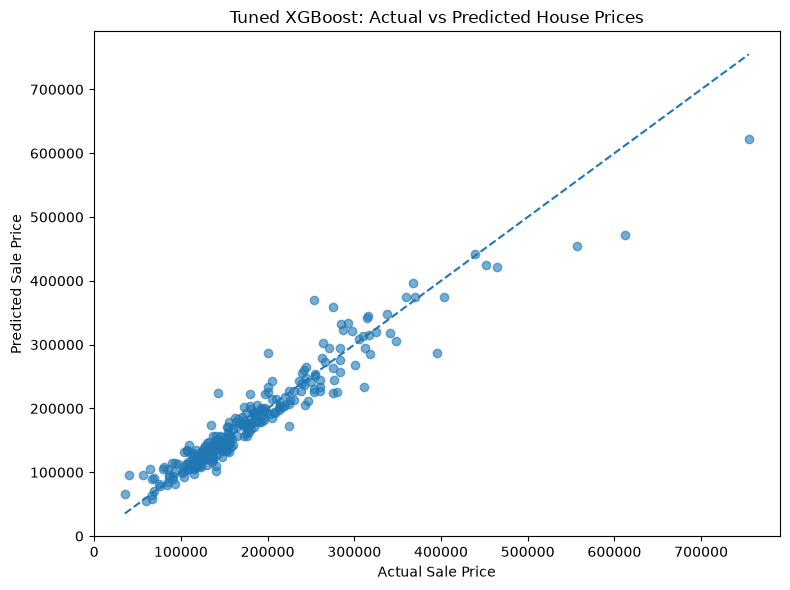

In [167]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, tuned_predictions, alpha=0.6)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Tuned XGBoost: Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.tight_layout()

plt.savefig("images/tuned_xgboost_actual_vs_predicted.png", dpi=300)

plt.show()

In [169]:
import joblib

joblib.dump(
    best_xgb,
    "models/tuned_xgboost_house_price_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


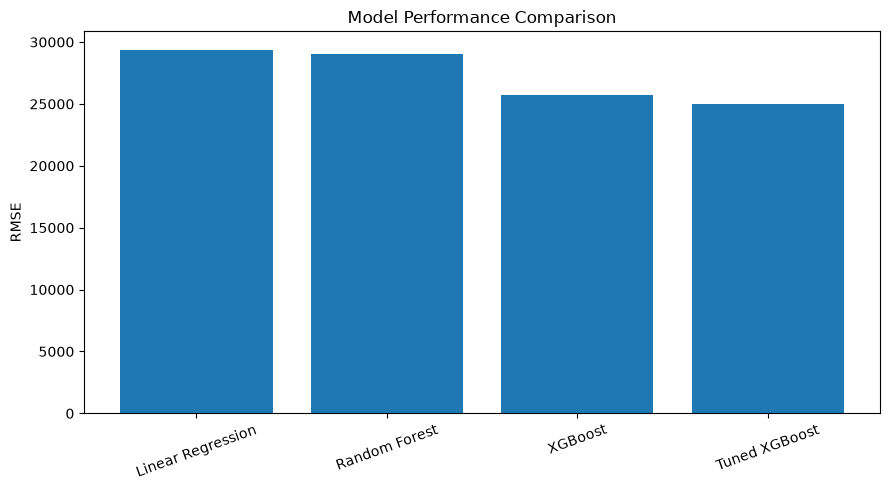

In [171]:
models = [
    "Linear Regression",
    "Random Forest",
    "XGBoost",
    "Tuned XGBoost"
]

rmse_values = [
    linear_rmse,
    rf_rmse,
    xgb_rmse,
    tuned_rmse
]

plt.figure(figsize=(9, 5))

plt.bar(models, rmse_values)

plt.ylabel("RMSE")
plt.title("Model Performance Comparison")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "images/model_performance_comparison.png",
    dpi=300
)

plt.show()